### Lab 7: K-mean Clustering

#### Step-by-Step Instructions:


In [1]:
# Hello everyone, in this lab, we'll walk through a K-means clustering example using synthetic e-commerce data.
# We'll use pandas for data manipulation, matplotlib for plotting, and sklearn for clustering tasks.

import pandas as pd  # Importing pandas for data manipulation
import numpy as np  # Importing numpy for numerical operations
from sklearn.cluster import KMeans  # Importing KMeans from sklearn for clustering
import matplotlib.pyplot as plt  # Importing matplotlib for plotting
import warnings  # Importing warnings to manage warning messages

# We'll ignore any warnings to keep our output clean.
warnings.filterwarnings('ignore')  # This will suppress any warning messages

# Let's start by loading our dataset into a pandas DataFrame.
ecom_data = pd.read_csv('E-COM_SYNTH.csv')  # Reading the CSV file into a DataFrame

# Displaying the last 5 rows of the dataset to get an idea of what it looks like.
print(ecom_data.tail())  # Displaying the last 5 rows of the DataFrame



     Total_Spend  Number_of_Orders  Average_Order_Value
745      4502.89                21               833.38
746      1950.26                47               280.34
747      2740.59                80               522.90
748      4537.04                59               305.74
749      3139.98                84               941.27


In [2]:
# Initializing an empty list to store inertia values for different numbers of clusters.
inertia_values = []
# Defining a range for the number of clusters to try.
training_range = range(2, 14)

# Looping over the range to create and fit KMeans models with different numbers of clusters.
for i in training_range:
    model = KMeans(n_clusters=i, random_state=3)  # Creating a KMeans model with i clusters
    model.fit(ecom_data)  # Fitting the model to the e-commerce data
    inertia_values.append(model.inertia_)  # Storing the inertia (sum of squared distances) for the model



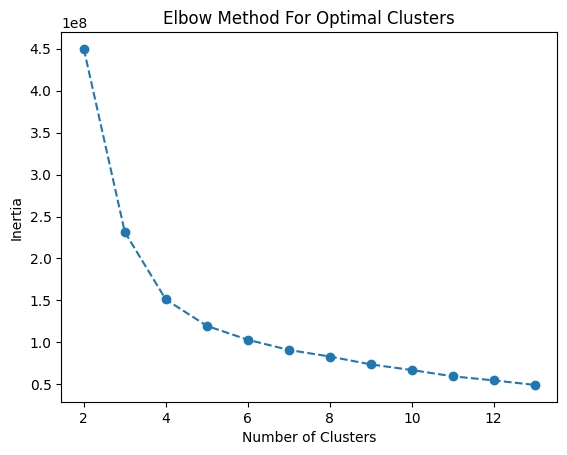

In [3]:
# Plotting the inertia values against the number of clusters to find the optimal number of clusters.
plt.plot(training_range, inertia_values, marker='o', linestyle='--')  # Plotting inertia values with markers and dashed lines
plt.xlabel('Number of Clusters')  # Labeling the x-axis
plt.ylabel('Inertia')  # Labeling the y-axis
plt.title('Elbow Method For Optimal Clusters')  # Adding a title to the plot
plt.show()  # Displaying the plot

#From this plot, we will find the elbow of the graph to select the optimal k for our problem

In [4]:
# Creating a final KMeans model with the chosen number of clusters (5 in this case).
final_model = KMeans(n_clusters=5, random_state=2)  # Creating a KMeans model with 5 clusters
final_model.fit(ecom_data)  # Fitting the model to the e-commerce data

# Adding the cluster labels to the dataset.
ecom_data['clusters'] = final_model.labels_  # Assigning the cluster labels to a new column in the DataFrame

# Displaying the first 10 rows of the dataset with the cluster labels.
print(ecom_data.head(10))  # Displaying the first 10 rows of the DataFrame



   Total_Spend  Number_of_Orders  Average_Order_Value  clusters
0      1903.97                51               403.62         3
1      4756.04                70               281.47         2
2      3673.37                 6               984.14         4
3      3013.36                67               415.24         0
4       822.29                 7               895.16         1
5       822.17                51               237.66         1
6       337.51                72               220.97         1
7      4337.57                42                40.82         2
8      3025.52                64               655.15         0
9      3554.96                15               374.84         4


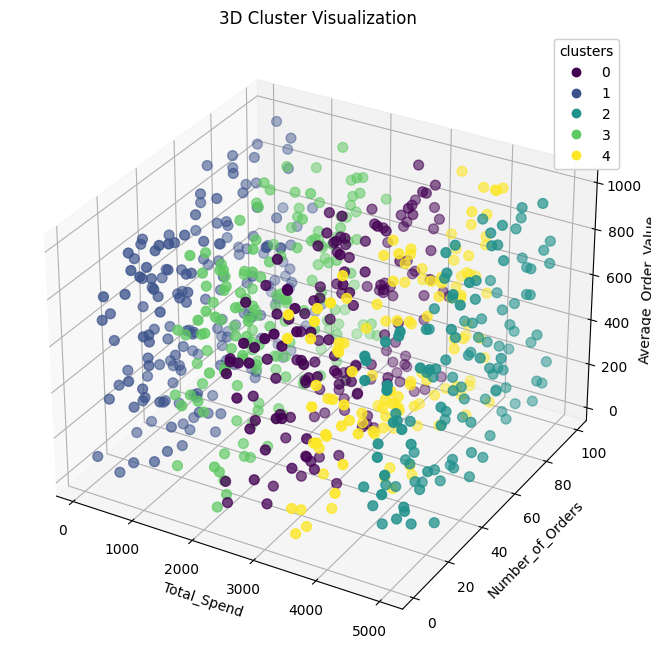

In [5]:
# Creating a 3D plot to visualize the clusters.
fig = plt.figure(figsize=(10, 8))  # Creating a new figure with a specified size (10 inches by 8 inches)
ax = fig.add_subplot(111, projection='3d')  # Adding a 3D subplot

# Selecting features for the 3D plot.
features = ['Total_Spend', 'Number_of_Orders', 'Average_Order_Value']

# Creating a scatter plot for the clusters in 3D space.
scatter = ax.scatter(ecom_data[features[0]],  # Plotting Total_Spend on the x-axis
                     ecom_data[features[1]],  # Plotting Number_of_Orders on the y-axis
                     ecom_data[features[2]],  # Plotting Average_Order_Value on the z-axis
                     c=ecom_data['clusters'], cmap='viridis', s=50)  # Coloring points by cluster and setting point size

# Labeling the axes.
ax.set_xlabel(features[0])  # Labeling the x-axis
ax.set_ylabel(features[1])  # Labeling the y-axis
ax.set_zlabel(features[2])  # Labeling the z-axis

# Adding a title to the plot.
ax.set_title('3D Cluster Visualization')  # Adding a title to the plot

# Adding a legend to the plot.
legend1 = ax.legend(*scatter.legend_elements(), title="clusters")  # Creating a legend for the clusters
ax.add_artist(legend1)  # Adding the legend to the plot

# Displaying the 3D plot.
plt.show()  # Displaying the plot


## Let's take a look at the flow we  followed for solving a clustering problem

Import Libraries:

We begin by importing necessary libraries including pandas for data manipulation, numpy for numerical operations, matplotlib for plotting, and sklearn for clustering tasks.
We also import warnings to suppress any unwanted warnings.
Load and Inspect Data:

We load the synthetic e-commerce data into a DataFrame using pandas.
We inspect the last few rows of the data to understand its structure and contents.
Determine Optimal Number of Clusters:

We initialize an empty list to store inertia values for different numbers of clusters.
We define a range for the number of clusters to try (from 2 to 13).
We loop over the range to create and fit KMeans models with different numbers of clusters, storing the inertia (sum of squared distances) for each model.
We plot the inertia values against the number of clusters to find the optimal number of clusters using the Elbow Method.
Train Final Model:

We create a final KMeans model with the chosen number of clusters (5 in this case).
We fit the model to the e-commerce data.
Add Cluster Labels:

We add the cluster labels to the dataset as a new column.
We inspect the first few rows of the dataset with the cluster labels to see the assigned clusters.
Visualize Clusters:

We create a 3D plot to visualize the clusters in a 3-dimensional space.
We select features (Total_Spend, Number_of_Orders, Average_Order_Value) for the 3D plot.
We create a scatter plot for the clusters in 3D space, color-coding the points by cluster.
We label the axes and add a title to the plot.
We add a legend to the plot to distinguish between clusters.
Finally, we display the 3D plot to visualize the clustering results.

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
df = pd.read_csv('CC GENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [20]:
df.drop('CUST_ID', axis=1, inplace=True)
df.dropna(inplace=True)
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0,8,1800.0,1400.057770,2407.246035,0.000000,12


In [21]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df)

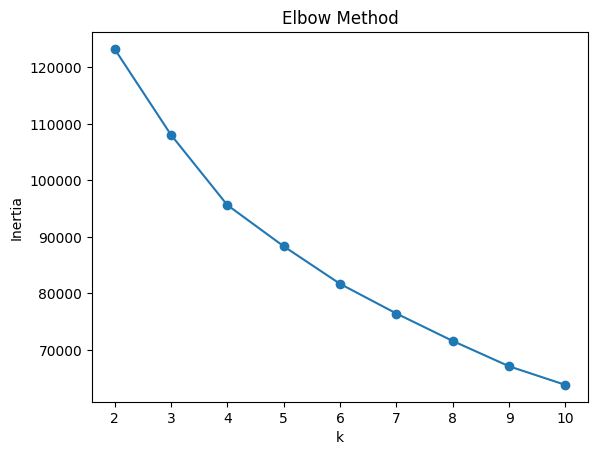

In [23]:
inertias = []
for k in range(2, 11):
    model = KMeans(n_clusters=k)
    model.fit(scaled)
    inertias.append(model.inertia_)

plt.plot(range(2, 11), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [24]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(scaled)
df['Cluster'] = kmeans.labels_

In [25]:
print("Inertia:", kmeans.inertia_)
print(df.groupby('Cluster').mean())

Inertia: 95646.59345636383
             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0         913.099184           0.946169  1264.675431        611.072630   
1        4655.121148           0.969212   505.501029        319.814377   
2        3586.147809           0.986840  7816.070736       5194.559518   
3        1061.245064           0.818901   273.943703        210.942878   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                    653.884203    218.409256             0.887404   
1                    185.774602   4585.995163             0.290473   
2                   2623.034061    658.230083             0.944589   
3                     63.279848    606.661232             0.174488   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                           

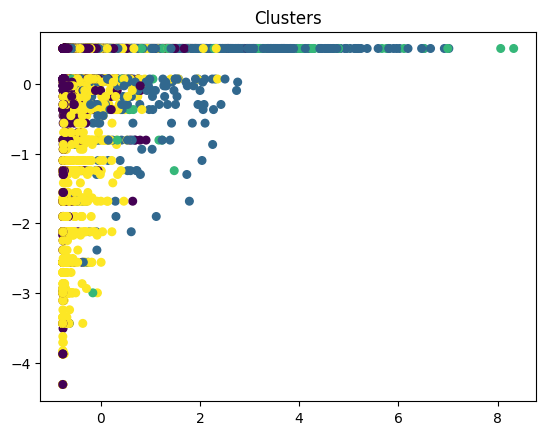

In [26]:
plt.scatter(scaled[:, 0], scaled[:, 1], c=df['Cluster'], cmap='viridis', s=30)
plt.title('Clusters')
plt.show()

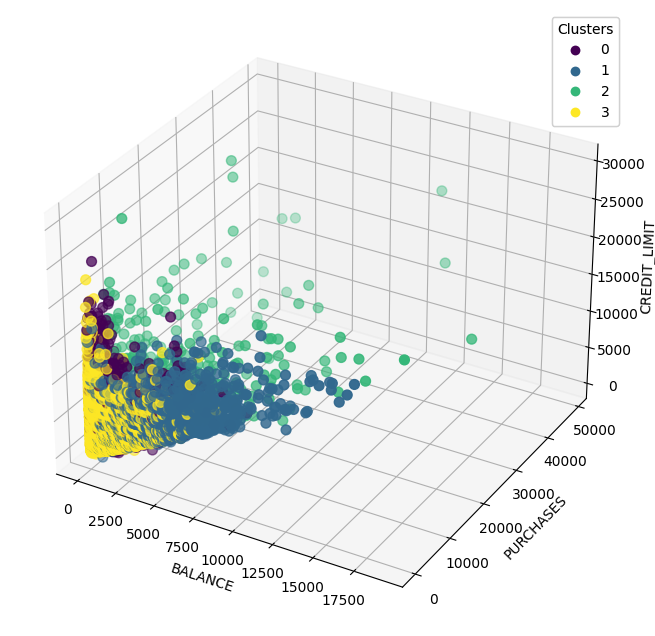

In [31]:
features = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df[features[0]],
    df[features[1]],
    df[features[2]],
    c=df['Cluster'],
    cmap='viridis',
    s=50
)

ax.set_xlabel(features[0])
ax.set_ylabel(features[1])
ax.set_zlabel(features[2])

legend = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend)

plt.show()

## Interpretation
- The model found 4 distinct customer groups based on credit behavior, with an inertia of **95,646.59**.
- Cluster 2 contains **high spenders** with large purchases and high credit limits, while Cluster 3 includes **low-activity users** with minimal transactions.
- The 3D plot shows **clear separation** between spending habits, useful for basic customer segmentation.